In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

In [3]:
def plot_pair_training_curve(target_path, dependent_path, title, metric_name = "Accuracy", x_max=None, labels=[], normalize=False):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t")
    plt.figure(figsize=(24, 6))
    # make the x axis logarithmic
    #plt.yscale('log')
    for index, row in df_target.iterrows():
        x_target, y_target = [int(x) for x in df_target.columns[1:]], row[1:]
        # normalize the y_target values by the first value of y_target
        if normalize:
            y_target = [(y - y_target.iloc[0]) / (y_target.iloc[-1] - y_target.iloc[0]) for y in y_target]
        
        if x_max is not None:
            x_target = x_target[:x_max]
            y_target = y_target[:x_max]
        spline = UnivariateSpline(x_target, y_target, s=0.1)
        y_smooth = spline(x_target)
        if len(labels) > 0:
            plt.plot(x_target, y_smooth, label=labels[0])
        else:
            plt.plot(x_target, y_target, label=f'Dataset 1')
        #plt.plot(x_target, y_smooth, label=f'Layer {index+1} Target')

        x_dependent, y_dependent = [int(x) for x in df_dep.columns[1:]], df_dep.iloc[index][1:]
        if x_max is not None:
            x_dependent = x_dependent[:x_max]
            y_dependent = y_dependent[:x_max]
        if normalize:
            y_dependent = [(y - y_dependent.iloc[0]) / (y_dependent.iloc[-1] - y_dependent.iloc[0]) for y in y_dependent]
        if len(labels) > 0:
            plt.plot(x_dependent, y_dependent, label=labels[1])
        else:
            plt.plot(x_dependent, y_dependent, label=f'Dataset 2')
    
    # draw a vertical line at x = 20000
    plt.axvline(x=2100, color='r', linestyle='--')

    plt.xlabel('Step')
    plt.ylabel(metric_name)
    #plt.yticks([0.5, 0.6, 0.8, 0.85, 0.9, 0.95, 1])
    plt.xticks(np.arange(min(x_dependent), max(x_dependent)+1, 100))
    plt.title(title)
    plt.legend()
    plt.show()

In [4]:
def plot_pair_training_curve_twinx(target_path, dependent_path, title, metric_name="Accuracy", x_max=None, labels=[], normalize=False):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t")

    fig, ax1 = plt.subplots(figsize=(24, 6))
    
    # Plot on left y-axis (ax1)
    for index, row in df_target.iterrows():
        x_target, y_target = [int(x) for x in df_target.columns[1:]], row[1:]
        if normalize:
            y_target = [(y - y_target.iloc[0]) / (y_target.iloc[-1] - y_target.iloc[0]) for y in y_target]
        
        if x_max is not None:
            x_target = x_target[:x_max]
            y_target = y_target[:x_max]
        
        ax1.plot(x_target, y_target, label=labels[0] if len(labels) > 0 else 'Dataset 1', color='blue')
    
    ax1.set_xlabel('Step')
    ax1.set_ylabel(f'{metric_name} (Target)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Add second y-axis (ax2)
    ax2 = ax1.twinx()
    
    for index, row in df_dep.iterrows():
        x_dependent, y_dependent = [int(x) for x in df_dep.columns[1:]], df_dep.iloc[index][1:]
        if normalize:
            y_dependent = [(y - y_dependent.iloc[0]) / (y_dependent.iloc[-1] - y_dependent.iloc[0]) for y in y_dependent]

        if x_max is not None:
            x_dependent = x_dependent[:x_max]
            y_dependent = y_dependent[:x_max]

        ax2.plot(x_dependent, y_dependent, label=labels[1] if len(labels) > 0 else 'Dataset 2', color='green')
    
    ax2.set_ylabel(f'{metric_name} (Dependent)', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Add vertical line
    ax1.axvline(x=2100, color='r', linestyle='--')

    plt.title(title)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.show()


# Ditransitives

## Number of tokens in top 75%

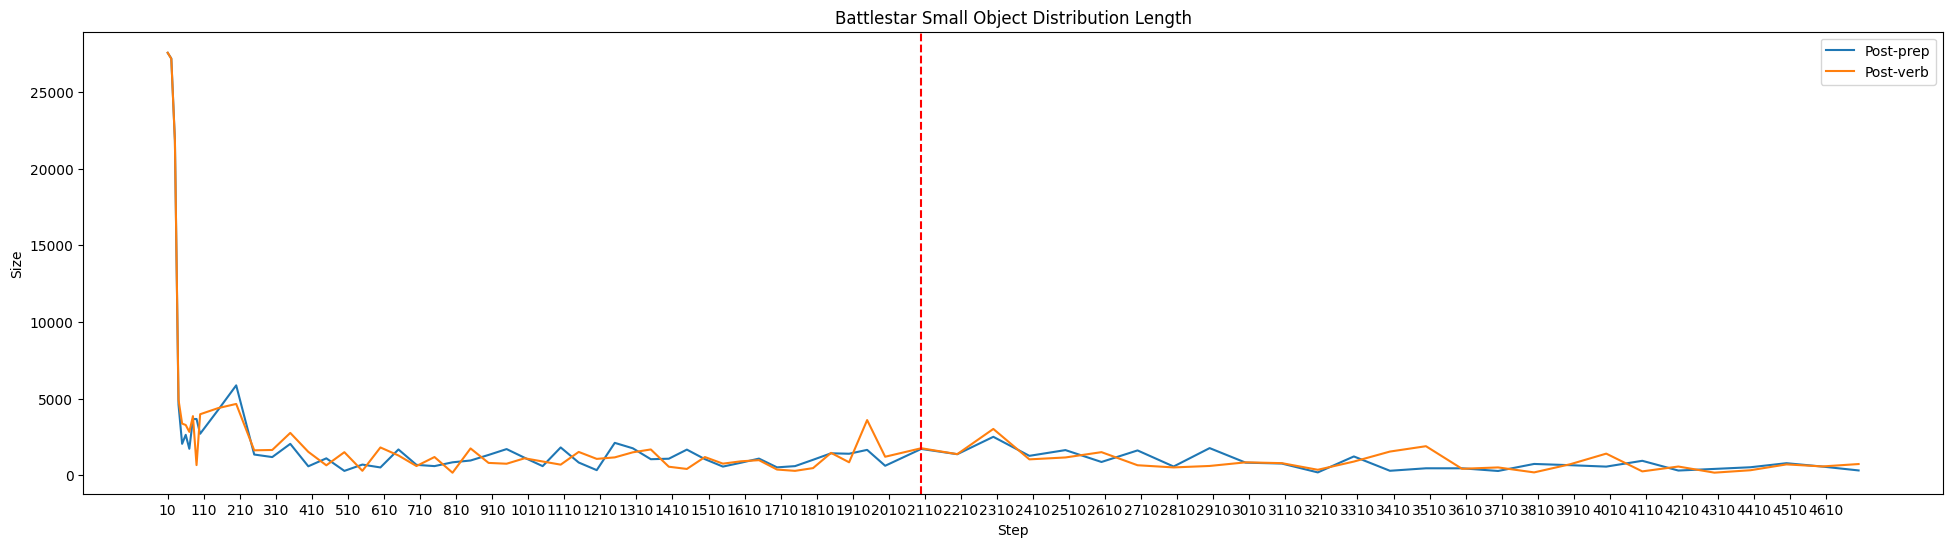

In [23]:
post_prep = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.length.preposition_fragment.tsv"
post_verb = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/verb_fragment/battlestar_small.object_distribution.length.verb_fragment.tsv"

plot_pair_training_curve(post_prep, post_verb, "Battlestar Small Object Distribution Length", metric_name="Size", labels=["Post-prep", "Post-verb"], x_max=75, normalize=False)

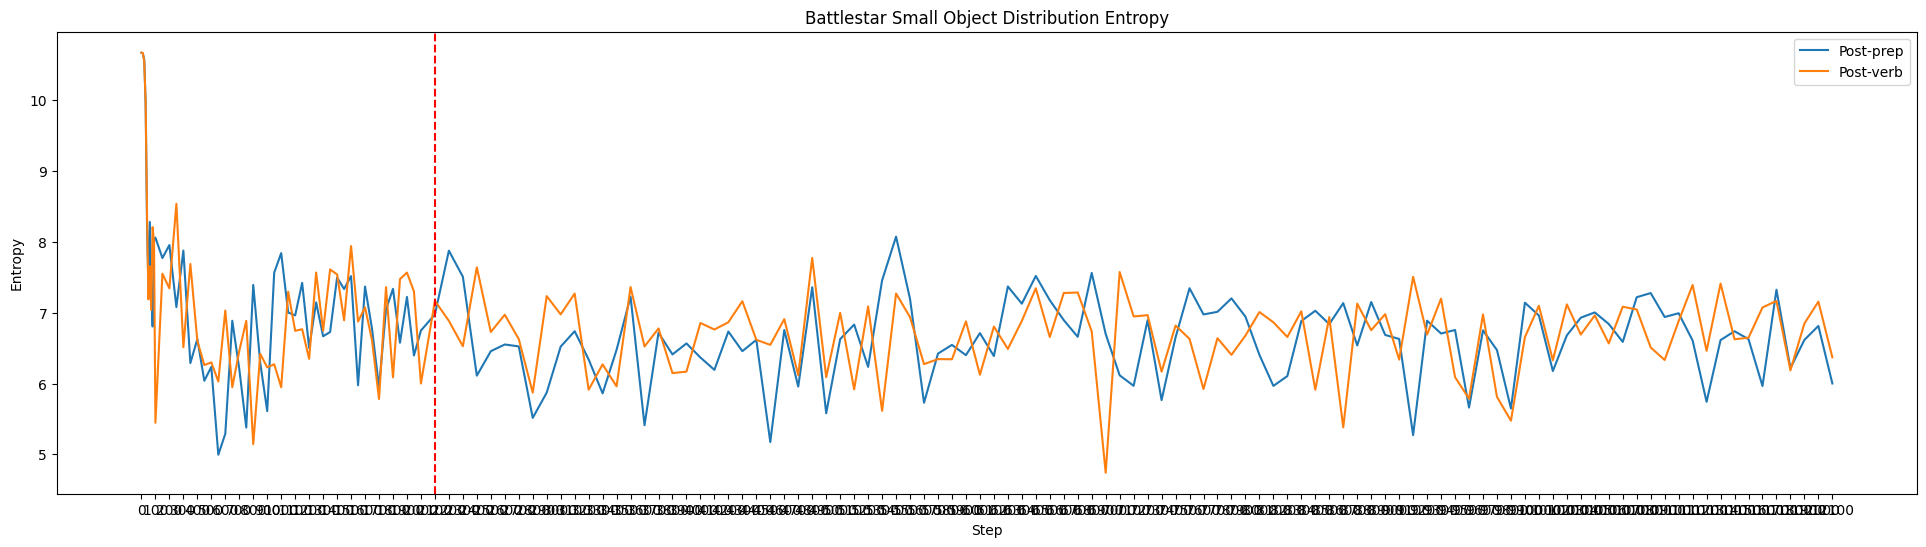

In [6]:
post_prep = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.tsv"
post_verb = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/verb_fragment/battlestar_small.object_distribution.entropy.verb_fragment.tsv"

plot_pair_training_curve(post_prep, post_verb, "Battlestar Small Object Distribution Entropy", metric_name="Entropy", labels=["Post-prep", "Post-verb"], x_max=1000, normalize=False)

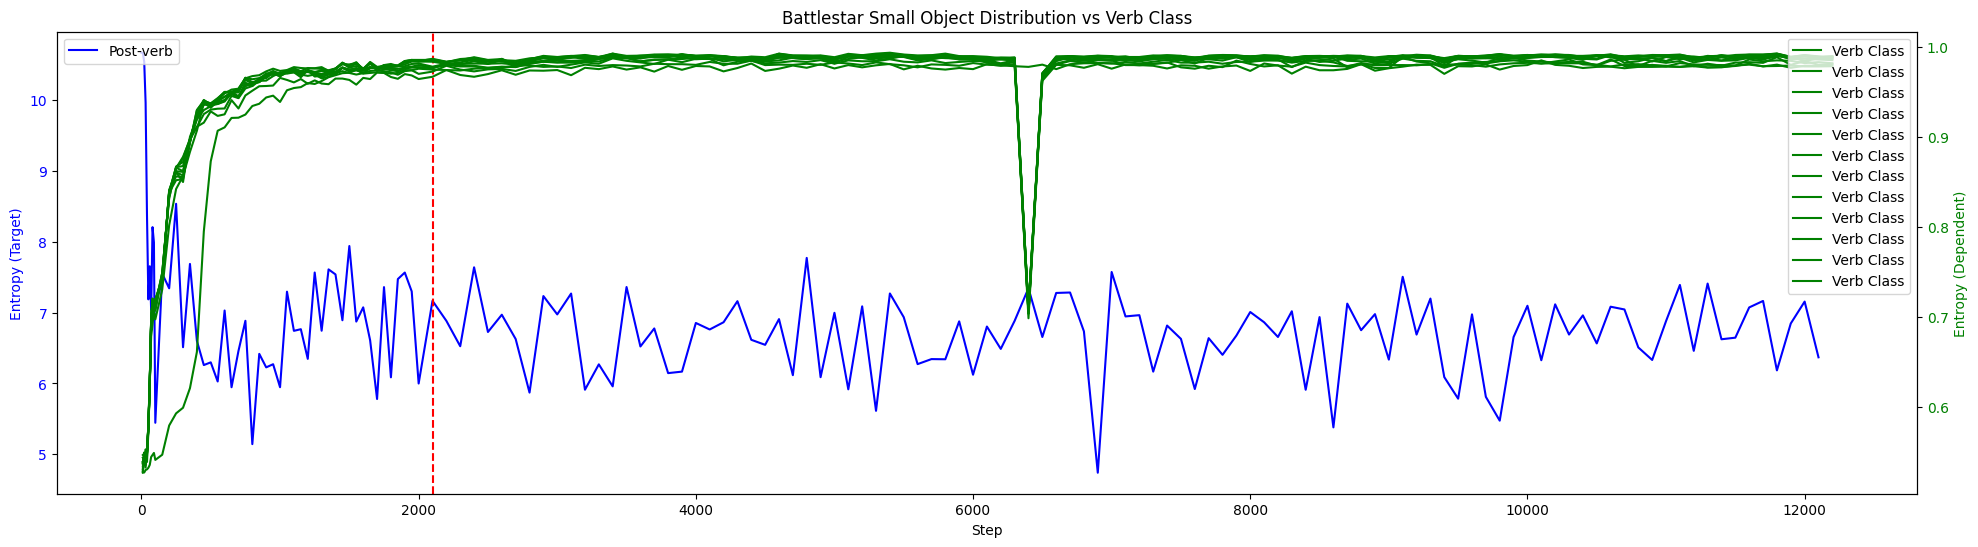

In [5]:
post_verb = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/verb_fragment/battlestar_small.object_distribution.entropy.verb_fragment.tsv"
verb_class = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_4/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"

plot_pair_training_curve_twinx(post_verb, verb_class, "Battlestar Small Object Distribution vs Verb Class", metric_name="Entropy", labels=["Post-verb", "Verb Class"], x_max=150, normalize=False)

# TODO: Verb-by-Verb analysis, vs. Class-by-class